In [65]:
import numpy as np
import jax.numpy as jnp
import matplotlib.pyplot as plt
import pandas as pd
from jax import config, random
import numpyro, jax
import numpyro.distributions as dist
from numpyro.infer import MCMC, NUTS, init_to_value
config.update('jax_enable_x64', True)
numpyro.set_platform('cpu')
num_chains = 4
numpyro.set_host_device_count(num_chains)
print ('# jax device count:', jax.local_device_count())

# jax device count: 4


In [66]:
import importlib_resources
from jnkepler.jaxttv.infer import *
from jnkepler.nbodytransit import *


In [67]:
import seaborn as sns
sns.set(style='ticks', font_scale=1.6, font='times')
plt.rcParams["figure.figsize"] = (12,6)
from matplotlib import rc

# Load data

In [68]:
d = pd.read_csv("data_1339/toi_1339_transit_data_all_planets.txt", sep="\s+", header=0, names=['Planet_num', 'Index', 'Tc', 'Tc_err'])
# d = pd.read_csv("toi_1339_transit_data_all.txt", sep="\s+", header=0, names=['Planet_num', 'Index', 'Tc', 'Tc_err'])

print(d)

     Planet_num  Index           Tc    Tc_err
0             1      0  1715.354632  0.001001
1             1      2  1733.116272  0.001416
2             1      3  1741.996592  0.001416
3             1      5  1759.758233  0.001416
4             1      6  1768.637553  0.002831
..          ...    ...          ...       ...
102           3     42  3354.302036  0.002238
103           3     43  3392.660442  0.001416
104           3     47  3546.073045  0.001001
105           3     49  3622.769837  0.002238
106           3     50  3661.127242  0.001416

[107 rows x 4 columns]


<>:1: SyntaxWarning: invalid escape sequence '\s'
<>:1: SyntaxWarning: invalid escape sequence '\s'
/var/folders/69/wlx91x8s1x34mphlfjy0h4pm0000gn/T/ipykernel_66744/1082065755.py:1: SyntaxWarning: invalid escape sequence '\s'
  d = pd.read_csv("data_1339/toi_1339_transit_data_all_planets.txt", sep="\s+", header=0, names=['Planet_num', 'Index', 'Tc', 'Tc_err'])


In [69]:
tcobs = [jnp.array(d.Tc[d.Planet_num==j+1]) for j in range(3)]
errorobs = [jnp.array(d.Tc_err[d.Planet_num==j+1]) for j in range(3)]
p_init = [8.88020257, 28.58140011, 38.35180318]


t_start = 1715.  # start of integration
t_end = 3670.
dt = 0.2 # integration timestep

In [70]:
# print(tcobs)
# print(errorobs)

In [71]:
# detrended light curves around transits; here simultaneous transit is excluded
dlc = pd.read_csv("TOI1339_lc_photodyn.csv")
time_obs = jnp.array(dlc['time'])
flux_obs = jnp.array(dlc['flux']) - 1.  # normalize around 0
error_obs = jnp.array(dlc['flux_err'])

# Get the sorting indices
sort_idx = np.argsort(time_obs)

# Apply the same reordering to all arrays
time_obs = time_obs[sort_idx]
flux_obs = flux_obs[sort_idx]
error_obs = error_obs[sort_idx]
print(time_obs)
print(dlc)

[1711.36577373 1711.36716265 1711.36855156 ... 3662.82669654 3662.82692802
 3662.8271595 ]
                time      flux  flux_err
0        1790.657779  0.999069  0.000578
1        1790.659168  0.999941  0.000580
2        1790.660557  0.999068  0.000580
3        1790.661946  0.999770  0.000579
4        1790.663335  0.999724  0.000579
...              ...       ...       ...
1954365  3662.826234  0.998714  0.000903
1954366  3662.826465  0.998010  0.000903
1954367  3662.826697  1.001218  0.000904
1954368  3662.826928  0.998057  0.000903
1954369  3662.827159  1.000882  0.000905

[1954370 rows x 3 columns]


In [72]:
window = 0.6  # days
time_segments, flux_segments, error_segments = [], [], []

planet_ids = []

for planet_idx, tplanet in enumerate(tcobs):
    for t0 in tplanet:
        mask = (time_obs > t0 - window) & (time_obs < t0 + window)
        time_segments.append(time_obs[mask])
        flux_segments.append(flux_obs[mask])
        error_segments.append(error_obs[mask])
        planet_ids.append(np.ones(np.sum(mask)) * planet_idx)

# Concatenate segments
time_obs_trim = np.concatenate(time_segments)
flux_obs_trim = np.concatenate(flux_segments)
error_obs_trim = np.concatenate(error_segments)
planet_ids = np.concatenate(planet_ids).astype(int)

time_obs = jnp.array(time_obs_trim)
flux_obs = jnp.array(flux_obs_trim)
error_obs = jnp.array(error_obs_trim)
planet_ids = jnp.array(planet_ids)  
print(time_obs)
print(len(time_obs))

[1714.75471244 1714.75610135 1714.75749026 ... 3661.72671895 3661.72695042
 3661.7271819 ]
385741


In [73]:
# Kepler long cadence in days
bin_width = 29.4 / 1440.0  # days (~0.02042 d, 29.4 min)

def bin_segment(t, f, e, pid, bin_width):
    """Bin one transit segment to bin_width (days)."""
    edges = np.arange(t.min(), t.max() + bin_width, bin_width)
    t_b, f_b, e_b, pid_b = [], [], [], []
    for i in range(len(edges) - 1):
        mask = (t >= edges[i]) & (t < edges[i+1])
        if not np.any(mask):
            continue
        w = 1.0 / e[mask]**2
        t_b.append(np.average(t[mask], weights=w))
        f_b.append(np.average(f[mask], weights=w))
        e_b.append(np.sqrt(1.0 / np.sum(w)))
        pid_b.append(pid)  # pid is a scalar, same for the whole segment
    return np.array(t_b), np.array(f_b), np.array(e_b), np.array(pid_b)

# Loop over all segments
binned = [bin_segment(t, f, e, pid[0] if np.ndim(pid) else pid, bin_width)
          for t, f, e, pid in zip(time_segments, flux_segments, error_segments, planet_ids)]

# Concatenate results
time_binned   = np.concatenate([b[0] for b in binned if len(b[0]) > 0])
flux_binned   = np.concatenate([b[1] for b in binned if len(b[1]) > 0])
error_binned  = np.concatenate([b[2] for b in binned if len(b[2]) > 0])
planet_binned = np.concatenate([b[3] for b in binned if len(b[3]) > 0])

# Save to dataframe
df_binned = pd.DataFrame({
    "time": time_binned,
    "flux": flux_binned,
    "flux_err": error_binned,
    "planet_number": planet_binned
})
df_binned.to_csv("toi1339_binned_lightcurves.csv", index=False)
print(f"Saved {len(df_binned)} binned points.")


Saved 6046 binned points.


In [74]:
time_obs = jnp.array(time_binned)
flux_obs = jnp.array(flux_binned)
error_obs = jnp.array(error_binned)
planet_ids = jnp.array(planet_binned)


In [75]:
print(tcobs[1][20])
transit_time = tcobs[1][20]
print(tcobs[2][3])
overlapping_transits = []

3640.93034948
1973.664185


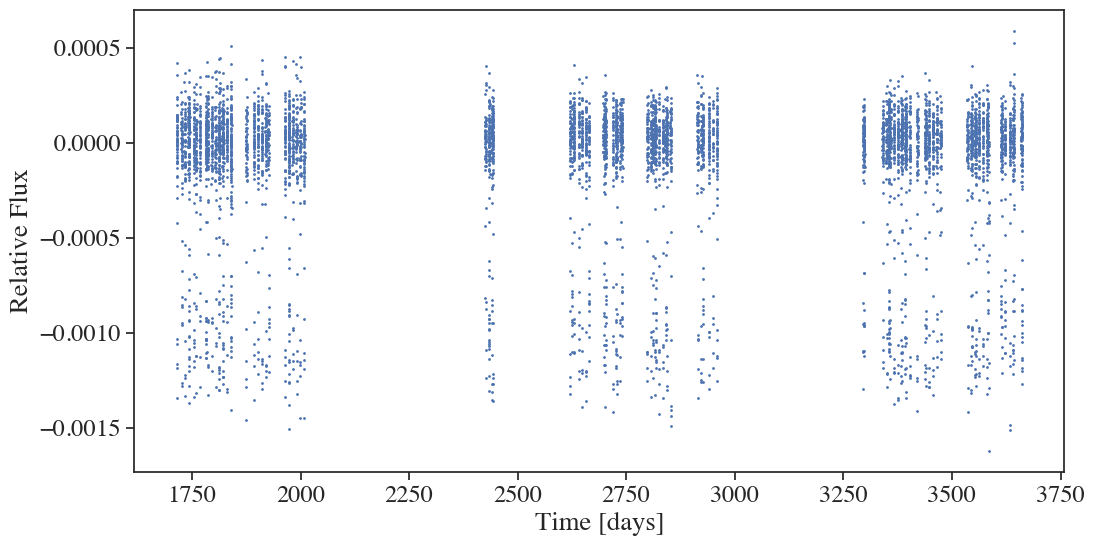

In [76]:
plt.scatter(time_obs, flux_obs, s=1)
plt.xlabel('Time [days]')
plt.ylabel('Relative Flux')
# plt.xlim(transit_time-0.6,transit_time+0.6)
plt.show()

# Initialize

In [77]:
nt = NbodyTransit(t_start, t_end, dt, tcobs, p_init, errorobs=errorobs, print_info=True)
nt.set_lcobs(time_obs)
# nt.set_lcobs(time_obs, exposure_time=2/1440.)
# nt.set_lcobs(time_obs, exposure_time=(1/3)/1440., supersample_factor=3)  # 20 second

# number of transiting planets:    3
# integration starts at:           1715.00
# first transit time in data:      1715.35
# last transit time in data:       3661.13
# integration ends at:             3670.00
# integration time step:           0.2000 (1/44 of innermost period)

# exposure time (min):             29.4
# supersampling factor:            10


/opt/homebrew/anaconda3/envs/tess-old/lib/python3.12/site-packages/jnkepler/nbodytransit/nbodytransit.py:72: UserWarning: set overlapping_transit to True if overlapping transits are present in the data.
  warnings.warn(


In [78]:
print(nt.times_lc)  # should be a JAX array of times
print(time_obs.shape, flux_obs.shape, error_obs.shape)
print([x.shape for x in tcobs])

[1714.76443518 1714.78526742 1714.8061016  ... 3661.68100284 3661.70137229
 3661.71942783]
(6046,) (6046,) (6046,)
[(71,), (21,), (15,)]


# TTV only optimization

In [105]:
param_bounds_ttv = ttv_default_parameter_bounds(nt)#, emax=0.5)
param_bounds_ttv['cosi'] = [jnp.ones(3)*0.9, jnp.ones(3)]
param_bounds_ttv['lnode'] = [jnp.ones(3)*-np.pi, jnp.ones(3)*np.pi]
# param_bounds_ttv['lnode'] = jnp.array([
#     [-np.pi,       -np.pi,       0.0],          # lower bounds
#     [np.pi,   np.pi,       1e-12]           # upper bounds
# ])

# running least squares optimization...
# objective function: 1329686.04 --> 146.67 (107 data)
# elapsed time: 34.0 sec


/opt/homebrew/anaconda3/envs/tess-old/lib/python3.12/site-packages/jnkepler/jaxttv/jaxttv.py:523: UserWarning: using t0 and P from a linear fit to the observed transit times.
  warnings.warn(


{'period': array([ 8.88031867, 28.58051756, 38.35163163]), 'ecosw': array([-0.00011203, -0.00153751,  0.00057052]), 'esinw': array([-0.0413725 ,  0.03789305,  0.0325777 ]), 'cosi': array([0.95501073, 0.90000897, 0.91639234]), 'lnode': array([ 0.49616168, -0.22233694, -0.04094343]), 'tic': array([1715.35224392, 1726.03046442, 1743.56875091]), 'lnpmass': array([-10.83060941, -12.2810883 , -12.72863134]), 'pmass': Array([1.97845464e-05, 4.63864480e-06, 2.96500649e-06], dtype=float64)}


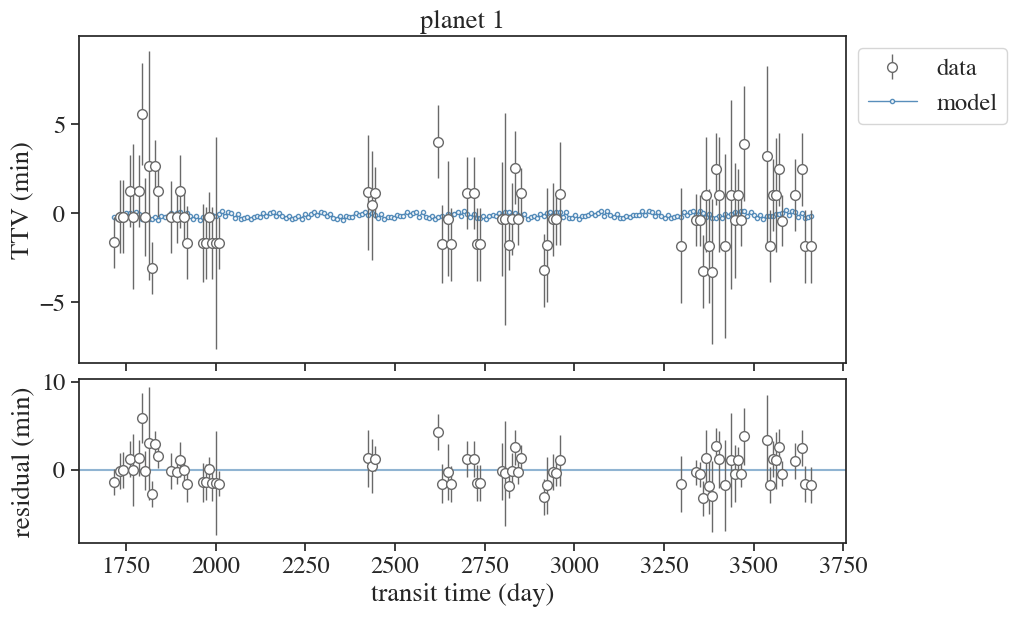

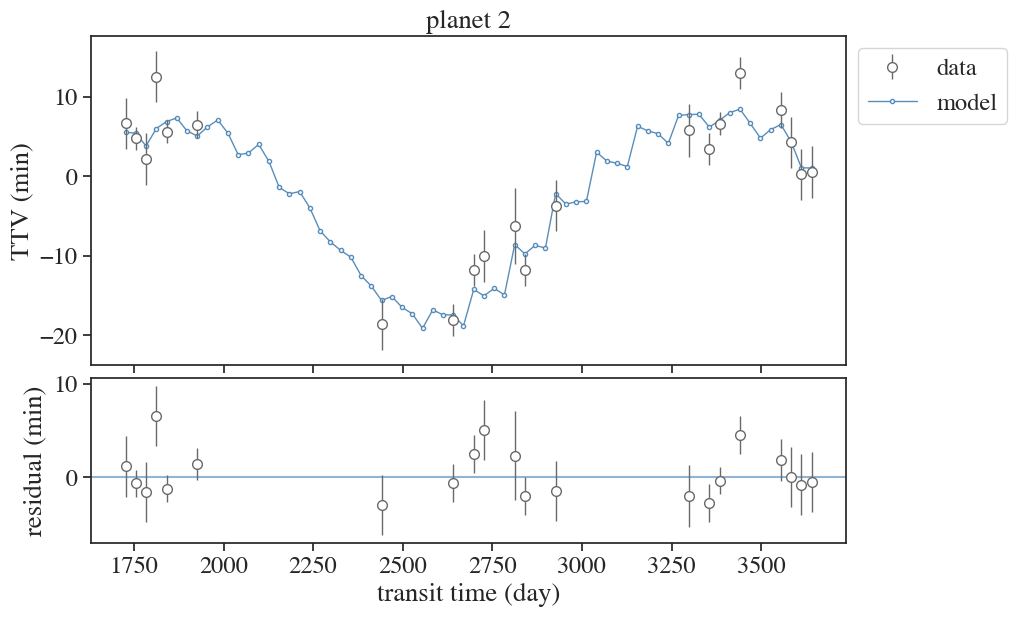

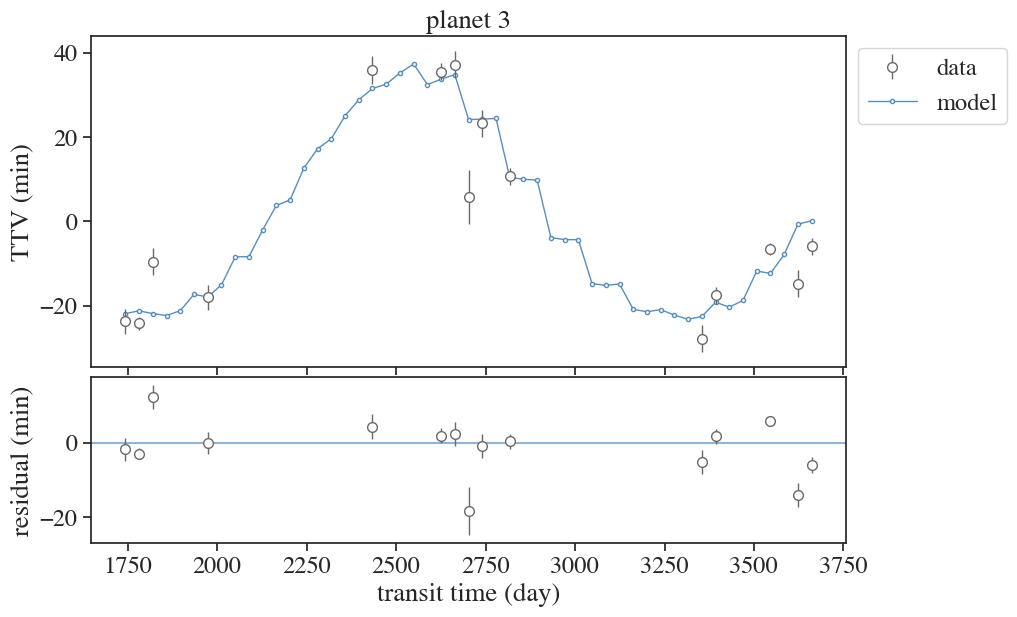

In [106]:
p_init = np.array([8.88020257, 28.58140011, 38.35180318,
                   0.16996202, -0.09855112, -0.0863744,
                   0.09494596, -0.04802669, -0.04114657,
                   1715.3554624, 1726.054591, 1743.55713087,
                   -10.3954937, -11.3564078 , -11.88909652,
])

popt = ttv_optim_curve_fit(nt, param_bounds_ttv)#, p_init=p_init)
print(popt)

# fractional energy error (symplectic, dt=2.00e-01): 7.97e-10
# fractional energy error (symplectic, dt=8.88e-03): 9.83e-13
# max difference in tc: 3.29e-06 days (0.28 sec)


sample: 100%|█| 1000/1000 [00:02<00:00, 345.87it/s, 3 steps of size 4.63e-01. ac



                mean       std    median      5.0%     95.0%     n_eff     r_hat
      lndf      1.33      0.38      1.30      0.73      1.92    199.44      1.00
     lnvar     -0.40      0.25     -0.39     -0.82     -0.02    135.66      1.01

Number of divergences: 0


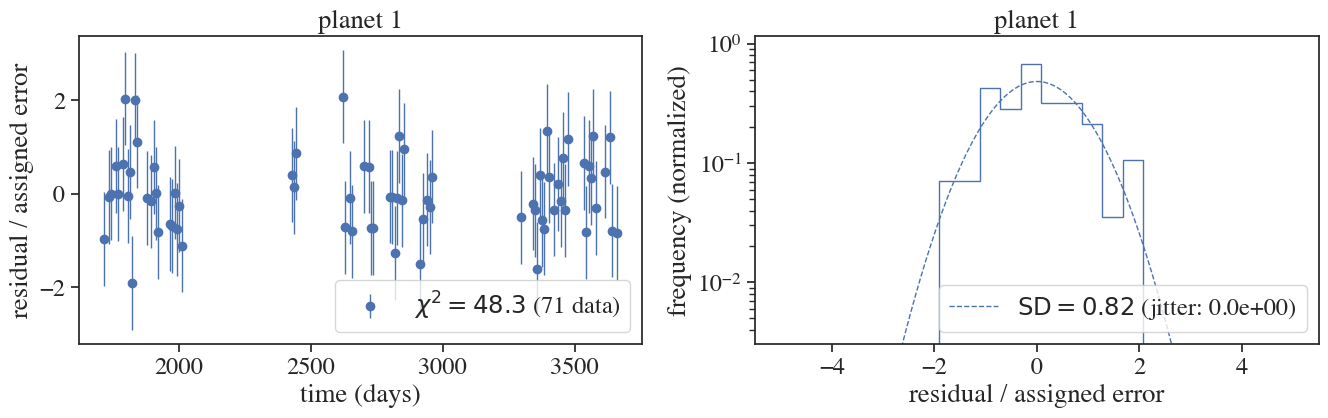

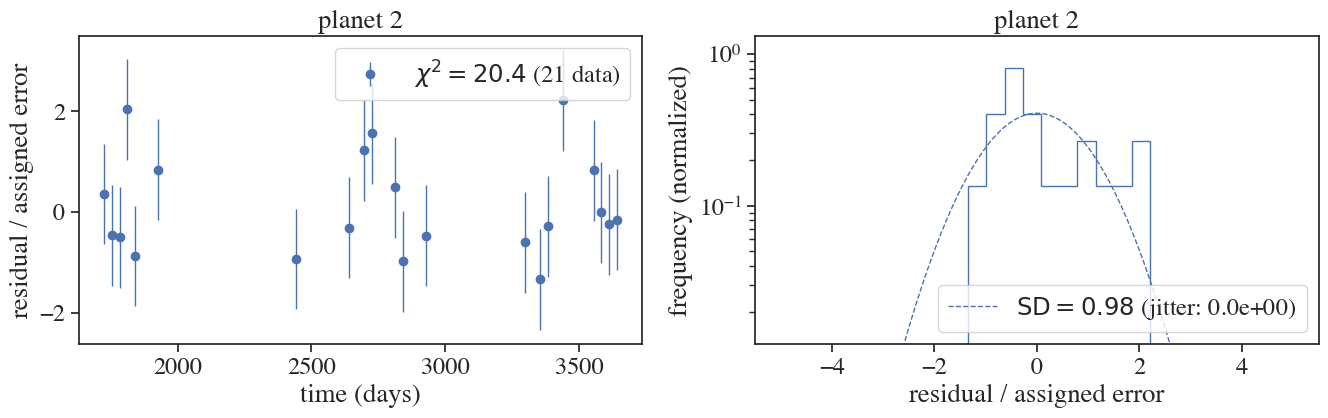

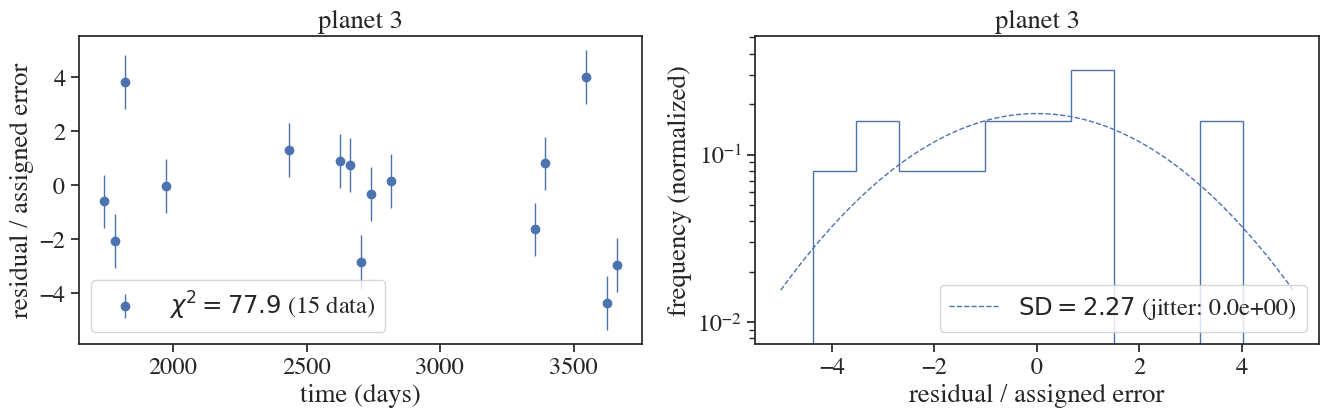

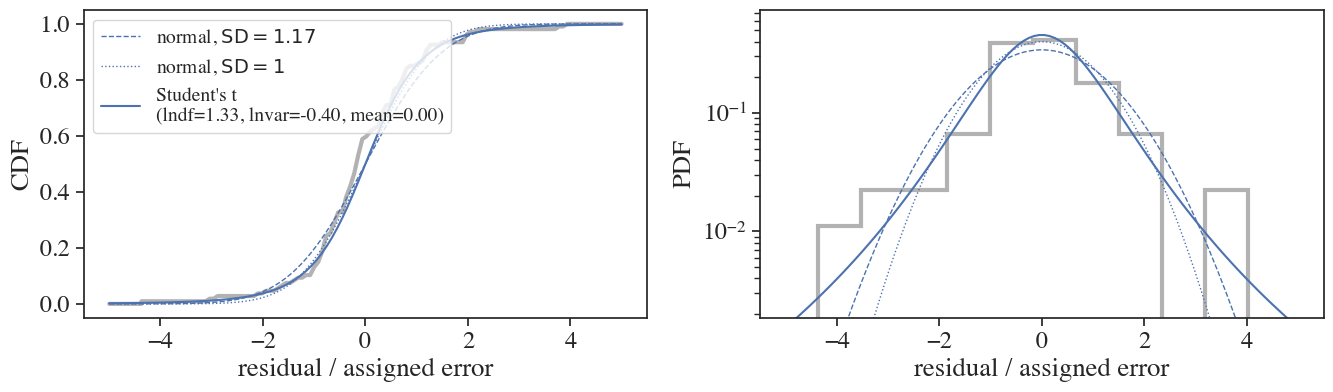

In [107]:
tc, _ = nt.check_timing_precision(popt)

pdic_normal, pdic_student = nt.check_residuals(popt)#, jitters=jitters)
plt.show()

In [19]:
# ## import pickle 
# with open('mcmc_runs/1339_jnkep_initial_fit_data_photodyn.pkl', 'wb') as f:
#     pickle.dump({'jttv': nt, 'popt': popt, 'param_bounds': param_bounds_ttv}, f)

# print('Initial fit data saved successfully')

# Transit parameter optimization

In [82]:
from jnkepler.infer import optim_svi

In [83]:
popt["smass"] = 0.81

In [84]:
# keys_ttv = ["ecosw", "esinw", "pmass", "period", "tic"]
# keys_transit = ["radius_ratio", "b", "srad", "q1", "q2", "meanflux"]
# param_bounds_transit = {
#     "q1": [jnp.array(0), jnp.array(1.)],
#     "q2": [jnp.array(0), jnp.array(1.)],
#     "radius_ratio":  [jnp.ones(3)*0.000001, jnp.ones(3)*0.07],
#     "b": [jnp.zeros(3), jnp.ones(3)*0.99],
#     "srad": [jnp.array(0.5), jnp.array(1.1)],
#     "meanflux": [jnp.array(-1e-4), jnp.array(1e-4)]
# }

keys_ttv = ["ecosw", "esinw","cosi", "lnode", "pmass", "period", "tic"]
keys_transit = ["srad"]
param_bounds_transit = {
    # "b": [jnp.zeros(3), jnp.ones(3)*0.9],
    "srad": [jnp.array(0.75), jnp.array(1.25)],
}


In [89]:
###  values from lubin 2022
rho_star = 1.37 #[g/cm^3] 
rho_star_err = 0.11 #/10

T14_1 = 3.1* 0.0416667
T14_1_err = (0.1 * 0.0416667)
b_1 = 0.62
b_1_err = 0.02
rp_1 = 0.0336
rp_1_err = 0.0007

T14_2 = 4.5 * 0.0416667
T14_2_err = (0.2 * 0.0416667) #/ 10
b_2 = 0.63
b_2_err = 0.02 #/10
rp_2 = 0.0306
rp_2_err = 0.0007 #/ 10

T14_3 = 5.5 * 0.0416667
T14_3_err =(0.30 * 0.0416667) #/ 10
b_3 = 0.48
b_3_err = 0.04 #/ 10
rp_3 = 0.0302
rp_3_err = 0.0007 #/ 10

rp_rs_lit = [rp_1, rp_2, rp_3]
rp_rs_err = [rp_1_err, rp_2_err, rp_3_err]
b_lit = [b_1, b_2, b_3]
b_err = [b_1_err, b_2_err, b_3_err]
T14_lit = [T14_1, T14_2, T14_3]         # in days
T14_err = [T14_1_err, T14_2_err, T14_3_err]
rho_star_lit = rho_star
rho_star_err = rho_star_err

### make usable in function 
# Transit durations (T14) in days
dur_obs_flat = jnp.array(T14_lit)       
dur_err_flat = jnp.array(T14_err)

# Impact parameters
b_obs_flat = jnp.array(b_lit)
b_err_flat = jnp.array(b_err)

# Optional: planet radii ratios
rp_obs_flat = jnp.array(rp_rs_lit)
rp_err_flat = jnp.array(rp_rs_err)

# Stellar density prior
rho_star_mean = rho_star_lit  # g/cm^3
rho_star_sigma = rho_star_err

#######
planet_ids_tc = jnp.concatenate([jnp.ones(len(tc)) * i for i, tc in enumerate(tcobs)]).astype(int)

dur_obs_per_transit = dur_obs_flat[planet_ids_tc]
dur_err_per_transit = dur_err_flat[planet_ids_tc]

b_obs_per_transit = b_obs_flat[planet_ids_tc]
b_err_per_transit = b_err_flat[planet_ids_tc]

rp_obs_per_transit = rp_obs_flat[planet_ids_tc]
rp_err_per_transit = rp_err_flat[planet_ids_tc]


# Flatten tcobservations (same ordering as nt expects — ensure this ordering matches nt.get_xvsky_tc)
tc_obs_flat = jnp.concatenate([t for t in tcobs])
tc_err_flat = jnp.concatenate([e for e in errorobs])


from astropy.constants import M_sun, R_sun, G

# Convert stellar density prior to SI units (kg/m^3)
rho_star_mean_SI = (rho_star_mean * 1e3)  # g/cm^3 -> kg/m^3
rho_star_sigma_SI = (rho_star_sigma * 1e3)
# 1 g/cm^3 = 1000 kg/m^3

# Stellar mass in kg
smass_si = 0.81* M_sun.value  # fixed mass in kg

In [90]:
from astropy import units as u
from astropy.constants import R_sun
# Convert R_sun to AU outside
R_sun_AU = (R_sun.to(u.au)).value  # float, JAX-compatible

def compute_b_and_duration_from_xv(xsky_tc, vsky_tc, srad, smass):
    """
    xsky_tc: array shape (ntransits, 2) (AU) -- sky-plane position (x,y) in AU
    vsky_tc: array shape (ntransits, 2) (AU/day) -- sky-plane velocity
    srad: stellar radius in Rsun
    smass: stellar mass in Msun
    returns:
      b_model: impact parameter
      dur_model: approximate T14 in days
    """
    # stellar radius in AU (JAX-friendly float)
    Rstar_AU = srad * R_sun_AU

    sep = jnp.sqrt(xsky_tc[:,0]**2 + xsky_tc[:,1]**2)  # AU
    b_model = sep / Rstar_AU

    vperp = jnp.sqrt(vsky_tc[:,0]**2 + vsky_tc[:,1]**2)
    vperp = jnp.where(vperp <= 0, 1e-8, vperp)

    sqrt_term = jnp.sqrt(jnp.clip(1.0 - b_model**2, a_min=0.0))
    dur_model = 2.0 * Rstar_AU * sqrt_term / vperp

    return b_model, dur_model

In [91]:
import celerite2
from celerite2.jax import terms as jax_terms

def model_fix_ttv(par_dict, param_bounds_transit, tc_obs_flat, tc_err_flat, dur_obs_flat, dur_err_flat, b_obs_flat, b_err_flat):
    par = {}

    for key in keys_ttv + ["smass"]:
        par[key] = par_dict[key]

    # Convert (fixed) rho priors (already corrected earlier):
    rho_mu_SI = rho_star_mean_SI     # from earlier corrected conversion
    rho_sigma_SI = rho_star_sigma_SI
    
    # fractional sigma (use reasonable floor)
    frac_sigma = jnp.clip(rho_sigma_SI / rho_mu_SI, 1e-3, 2.0)
    rho_log_mu = jnp.log(rho_mu_SI)
    rho_log_sigma = frac_sigma
    
    # sample lognormal rho to guarantee positivity
    rho_star_sample = numpyro.sample("rho_star", dist.LogNormal(rho_log_mu, rho_log_sigma))
    
    # compute stellar radius in SI with safety floor
    eps = 1e-12
    srad_si = (3.0 * smass_si / (4.0 * jnp.pi * jnp.clip(rho_star_sample, a_min=eps)))**(1/3)
    srad_Rsun = srad_si / R_sun.value
    par["srad"] = numpyro.deterministic("srad", srad_Rsun)

    
    # 6️⃣ Other transit parameters (if any)
    for key in keys_transit:
        if key != "srad":  # we already handle srad via rho_star
            par[key+"_scaled"] = numpyro.sample(
                key+"_scaled", dist.Uniform(param_bounds_transit[key][0]*0, param_bounds_transit[key][0]*0 + 1.)
            )
            par[key] = numpyro.deterministic(
                key, par[key+"_scaled"] * (param_bounds_transit[key][1] - param_bounds_transit[key][0]) + param_bounds_transit[key][0]
            )
    tcmodel, xsky_tc, vsky_tc, times, xvjac, masses = nt.get_xvsky_tc(par)
    # flatten tcmodel to match the expected flattened observations
    tcmodel = numpyro.deterministic("tcmodel", jnp.array(tcmodel).reshape(-1))
    numpyro.deterministic("xsky_tc", xsky_tc)
    numpyro.deterministic("vsky_tc", vsky_tc)
    
    # compute b and durations from x & v
    b_model, dur_model = compute_b_and_duration_from_xv(jnp.array(xsky_tc).reshape(-1,2),
                                                        jnp.array(vsky_tc).reshape(-1,2),
                                                        par["srad"], par["smass"])
    numpyro.deterministic("b_model", b_model)
    numpyro.deterministic("dur_model", dur_model)

    # observational uncertainties are provided as arguments; assume independent Gaussian noise.
    # Timing likelihood:
    numpyro.sample("tc_obs", dist.Normal(tcmodel, tc_err_flat), obs=tc_obs_flat)

    # Duration likelihood:
    numpyro.sample("dur_obs", dist.Normal(dur_model, dur_err_flat), obs=dur_obs_flat)

    # Impact parameter likelihood:
    numpyro.sample("b_obs", dist.Normal(b_model, b_err_flat), obs=b_obs_flat)


    
    

    # # Simple iid Gaussian likelihood with jitter
    # lnjitter = numpyro.sample("lnjitter", dist.Uniform(-14, -4).expand([3]))
    # jitter = numpyro.deterministic("jitter", jnp.exp(lnjitter))

    # # Assign planet-specific jitter to each datapoint
    # point_jitter = numpyro.deterministic("point_jitter", jitter[planet_ids])
    
    # # Likelihood
    # numpyro.sample(
    #     "obs",
    #     dist.Normal(0.0, jnp.sqrt(error_obs**2 + point_jitter**2)),
    #     obs=residual,
    # )

In [94]:
# 1) direct test of nt.get_xvsky_tc
par_test = popt.copy()
par_test["smass"] = 0.81

try:
    tcmodel_test, xsky_test, vsky_test, times_test, xvjac_test, masses_test = nt.get_xvsky_tc(par_test)
    print("tcmodel_test shape", jnp.array(tcmodel_test).shape)
    print("xsky_test finite?", jnp.isfinite(jnp.array(xsky_test)).all())
    print("vsky_test finite?", jnp.isfinite(jnp.array(vsky_test)).all())
    print("some tcmodel values (first 10):", jnp.array(tcmodel_test).reshape(-1)[:10])
except Exception as e:
    print("ERROR calling nt.get_xvsky_tc:", e)
    import traceback; traceback.print_exc()

tcmodel_test shape (107,)
xsky_test finite? True
vsky_test finite? True
some tcmodel values (first 10): [1715.35560626 1733.11637128 1741.99656354 1759.7572679  1768.63750492
 1786.39811727 1795.27843711 1804.1588315  1813.03907482 1821.9194508 ]


In [95]:
popt_transit = optim_svi(model_fix_ttv, 1e-2, 5000, 
                         p_initial = popt, 
                         par_dict=popt, 
                         param_bounds_transit=param_bounds_transit,
                         tc_obs_flat=tc_obs_flat,
                         tc_err_flat=tc_err_flat,
                         dur_obs_flat=dur_obs_per_transit,
                         dur_err_flat=dur_err_per_transit,
                         b_obs_flat=b_obs_per_transit,
                         b_err_flat=b_err_per_transit)

RuntimeError: Cannot find valid initial parameters. Please check your model again.

In [25]:
from scipy.stats import norm 
# def check_residuals(p):
#     bins = np.linspace(-7, 7, 100)
#     plt.yscale("log")
#     plt.xlabel("normalized residual from GP mean")
#     res = (p['residual'] - p["gppred"]) / error_obs
#     plt.hist(res, bins=bins, density=True, alpha=0.6, label="SD=%.2f"%np.std(res))
#     plt.ylim(plt.gca().get_ylim())
#     plt.plot(bins, norm.pdf(bins), color='gray', label='standard normal')
#     plt.legend(loc='best')
#     plt.ylabel("PDF");

def check_residuals(p):
    """
    Plot histogram of normalized residuals.
    
    Parameters
    ----------
    p : dict
        Dictionary containing 'residual' (flux_obs - model).
    error_obs : array-like
        Observational errors for normalization.
    """
    bins = np.linspace(-7, 7, 100)
    plt.figure()
    plt.yscale("log")
    plt.xlabel("Normalized residual")
    
    # Without GP: just normalize residuals by errors
    res = p['residual'] / error_obs
    
    plt.hist(res, bins=bins, density=True, alpha=0.6,
             label="SD = %.2f" % np.std(res))
    
    plt.plot(bins, norm.pdf(bins), color='gray', label='standard normal')
    plt.legend(loc='best')
    plt.ylabel("PDF")
    plt.show()

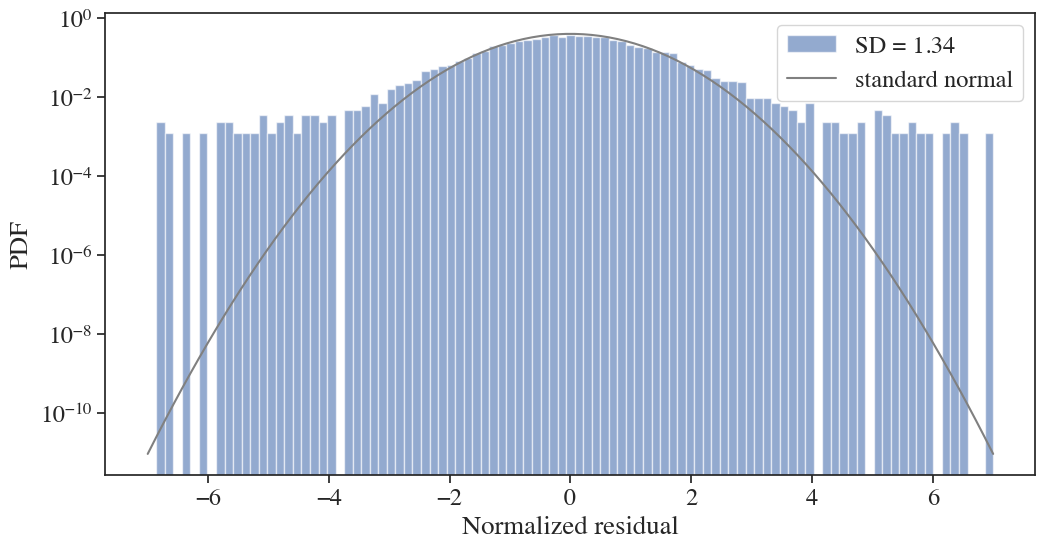

In [26]:
check_residuals(popt_transit)

In [27]:
# import jax, numpyro, celerite2
# print(jax.__version__)
# print(numpyro.__version__)
# print(celerite2.__version__)
print(popt_transit)

{'radius_ratio_scaled': Array([0.385946  , 0.35589018, 0.3383074 ], dtype=float64), 'radius_ratio': Array([0.03394595, 0.03169176, 0.03037306], dtype=float64), 'b': Array([0.67565165, 0.72123293, 0.62644937], dtype=float64), 'srad_scaled': Array(0.72307507, dtype=float64), 'srad': Array(1.11153754, dtype=float64), 'q1': Array(0.87160211, dtype=float64), 'q2': Array(0.18748249, dtype=float64), 'meanflux_scaled': Array(0.65925801, dtype=float64), 'meanflux': Array(3.18516018e-05, dtype=float64), 'tcmodel': Array([1715.35505671, 1733.11562943, 1741.99615974, 1759.75698407,
       1768.63759322, 1786.39840206, 1795.2787263 , 1804.15896907,
       1813.03927048, 1821.91944754, 1830.79963432, 1839.6799336 ,
       1875.20116429, 1892.9621838 , 1901.84263699, 1910.72314247,
       1919.60345538, 1964.00472361, 1972.88498544, 1981.76525245,
       1990.64552992, 1999.52599943, 2008.40637421, 2425.78273929,
       2434.66310023, 2443.54349594, 2621.14984853, 2630.03012123,
       2647.79063613,

## optimizing full photodynamical model

In [28]:
popt_ttv_scaled = scale_pdic(popt, param_bounds_ttv)
popt_full = popt_transit.copy()
popt_full.update(popt_ttv_scaled)

In [29]:
popt_full['lnode_innder'] = jnp.zeros(2)

In [30]:
def model_full(param_bounds_ttv, param_bounds_transit, 
               tc_obs_flat, tc_err_flat,
               dur_obs_flat, dur_err_flat,
               b_obs_flat, b_err_flat):
    """full photodynamical model
    
        - noise model is iid gaussian; we could've used other noise model (e.g., GP, Student's t)
        - we could've fitted mean flux as well
        - stellar mass is fixed to 1Msun and only radius is floated, because only mean stellar density is constrained from this model;
          so pmass is mass ratio and stellar radius (srad) is in units of Rsun/(Mstar/Msun)**(1./3.)
        - impact parameters are restricted to be positive but this could be relaxed
        - longitude of ascending node (lnode) is measured with respect to the outermost transiting planet

    """
    # fix stellar mass to 1Msun without losing generality
    par = {"smass": 0.81}

    # TTV parameters
    for key in keys_ttv:
        par[key+"_scaled"] = numpyro.sample(key+"_scaled", dist.Uniform(param_bounds_ttv[key][0]*0, param_bounds_ttv[key][0]*0+1.))
        par[key] = numpyro.deterministic(key, par[key+"_scaled"] * (param_bounds_ttv[key][1] - param_bounds_ttv[key][0]) + param_bounds_ttv[key][0])

    # add longitude of ascending node; prior Unif(-1, 1)
    lnode_inner = numpyro.sample("lnode_inner", dist.Uniform(-jnp.ones(2), jnp.ones(2)))
    par["lnode"] = numpyro.deterministic("lnode", jnp.hstack([lnode_inner, 0.]))

    # Jacobian for uniform ecc prior
    ecc = numpyro.deterministic("ecc", jnp.sqrt(par['ecosw']**2+par['esinw']**2))
    numpyro.factor("eprior", -jnp.log(ecc))

    rho_star_sample = numpyro.sample("rho_star", dist.Normal(rho_star_mean, rho_star_sigma))

    # transit parameters (though note that b is used to fix inclination along with other TTV parameters)
    from astropy import units as u
    from astropy.constants import M_sun, R_sun
    
    # Sample stellar density (g/cm^3)
    rho_star_sample = numpyro.sample("rho_star", dist.Normal(rho_star_mean, rho_star_sigma))
    
    # Convert to SI units (kg/m^3)
    rho_si = (rho_star_sample * u.g / u.cm**3).to(u.kg / u.m**3).value
    
    # Stellar mass in kg
    smass_si = (par["smass"] * M_sun).value
    
    # Compute stellar radius from mean density
    srad_si = (3 * smass_si / (4 * jnp.pi * rho_si))**(1/3)
    
    # Convert to solar radii
    par["srad"] = numpyro.deterministic("srad", srad_si / R_sun.value)

    for key in keys_transit:
        if key != "srad":  # we already handle srad via rho_star
            par[key+"_scaled"] = numpyro.sample(
                key+"_scaled", dist.Uniform(param_bounds_transit[key][0]*0, param_bounds_transit[key][0]*0 + 1.)
            )
            par[key] = numpyro.deterministic(
                key, par[key+"_scaled"] * (param_bounds_transit[key][1] - param_bounds_transit[key][0]) + param_bounds_transit[key][0]
            )

    # compute sky-plane states and predicted transit times
    tcmodel, xsky_tc, vsky_tc, times, xvjac, masses = nt.get_xvsky_tc(par)
    tcmodel = jnp.array(tcmodel).reshape(-1)
    numpyro.deterministic("tcmodel", tcmodel)
    numpyro.deterministic("xsky_tc", xsky_tc)
    numpyro.deterministic("vsky_tc", vsky_tc)



    # compute b and durations
    b_model, dur_model = compute_b_and_duration_from_xv(jnp.array(xsky_tc).reshape(-1,2),
                                                        jnp.array(vsky_tc).reshape(-1,2),
                                                        par["srad"], par["smass"])
    numpyro.deterministic("b_model", b_model)
    numpyro.deterministic("dur_model", dur_model)

    # observational likelihoods (Gaussian)
    numpyro.sample("tc_obs", dist.Normal(tcmodel, tc_err_flat), obs=tc_obs_flat)
    numpyro.sample("dur_obs", dist.Normal(dur_model, dur_err_flat), obs=dur_obs_flat)
    numpyro.sample("b_obs", dist.Normal(b_model, b_err_flat), obs=b_obs_flat)



    
    # # compute model (tcmodel is not used)
    # fluxmodel, tcmodel = nt.get_flux(par)
    # numpyro.deterministic("tcmodel", tcmodel)
    # numpyro.deterministic("fluxmodel", fluxmodel)  

    # # GP likelihood  
    # residual = numpyro.deterministic("residual", flux_obs - fluxmodel - par["meanflux"])
    # numpyro.deterministic("normed_residual", residual / error_obs)
    # lna = numpyro.sample("lna", dist.Uniform(low=-14, high=-4))
    # lnc = numpyro.sample("lnc", dist.Uniform(low=-5, high=1))
    # lnjitter = numpyro.sample("lnjitter", dist.Uniform(low=-14, high=-4))
    # jitter = numpyro.deterministic("jitter", jnp.exp(lnjitter))
    
    # kernel = jax_terms.Matern32Term(sigma=jnp.exp(lna), rho=jnp.exp(lnc))
    # gp = celerite2.jax.GaussianProcess(kernel, mean=0.0)
    # gp.compute(nt.times_lc, diag=error_obs**2 + jitter**2)
    
    # numpyro.sample("obs", gp.numpyro_dist(), obs=residual)
    # numpyro.deterministic("gppred", gp.predict(residual))

    # Simple iid Gaussian likelihood with jitter
    # lnjitter = numpyro.sample("lnjitter", dist.Uniform(-14, -4).expand([3]))
    # jitter = numpyro.deterministic("jitter", jnp.exp(lnjitter))

    # # Assign planet-specific jitter to each datapoint
    # point_jitter = numpyro.deterministic("point_jitter", jitter[planet_ids])
    
    # # Likelihood
    # numpyro.sample(
    #     "obs",
    #     dist.Normal(0.0, jnp.sqrt(error_obs**2 + point_jitter**2)),
    #     obs=residual,
    # )

In [31]:
popt_full = optim_svi(model_full, 1e-2, 5000, 
                      p_initial=popt_transit, 
                      param_bounds_ttv=param_bounds_ttv, 
                      param_bounds_transit=param_bounds_transit,
                      tc_obs_flat=tc_obs_flat,
                      tc_err_flat=tc_err_flat,
                      dur_obs_flat=dur_obs_flat,
                      dur_err_flat=dur_err_flat,
                      b_obs_flat=b_obs_flat,
                      b_err_flat=b_err_flat)

100%|█| 5000/5000 [30:36<00:00,  2.72it/s, init loss: -38958.9680, avg. loss [47


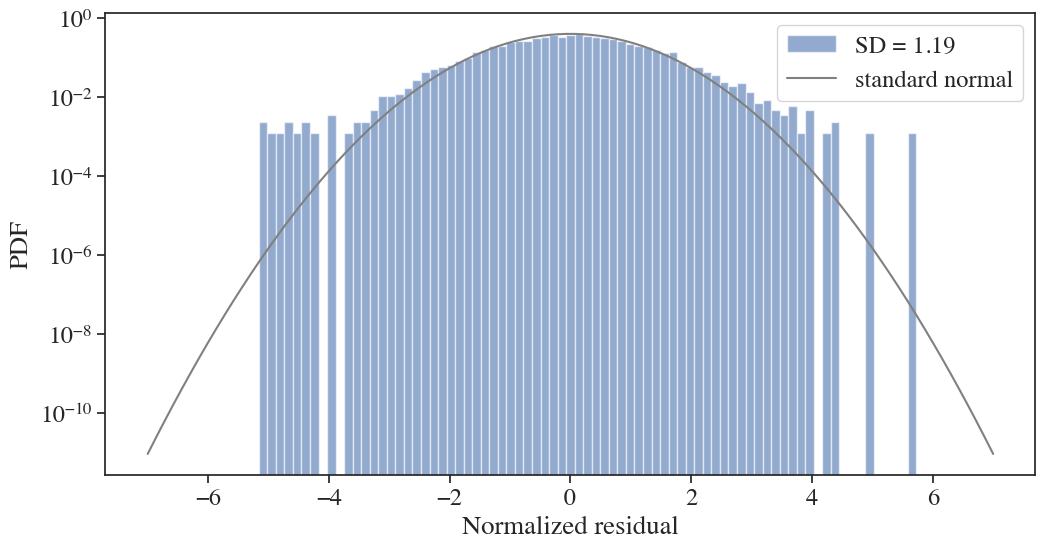

In [32]:
check_residuals(popt_full)

In [33]:
import pickle 
with open('1339_jnkep_initial_fit_photodyn.pkl', 'wb') as f:
    pickle.dump({'nt': nt, 
                 'popt_transit': popt_transit, 
                 'popt_full': popt_full, 
                 'param_bounds': param_bounds_ttv, 
                 'param_bounds_transit': param_bounds_transit, 'keys_ttv': keys_ttv, 'keys_transit': keys_transit}, f)

print('Initial fit data saved successfully')

Initial fit data saved successfully


# Running the HMC

In [34]:
import pickle

# Load the saved data
with open('1339_jnkep_initial_fit_photodyn.pkl', 'rb') as f:
    data = pickle.load(f)

# Access the variables
nt = data['nt']
popt_transit = data['popt_transit']
popt_full = data['popt_full']
param_bounds_ttv = data['param_bounds']
param_bounds_transit = data['param_bounds_transit']
keys_ttv = data['keys_ttv']
keys_transit = data['keys_transit']


In [35]:
print(popt_transit)
print('\n')
print(popt_full)

{'radius_ratio_scaled': Array([0.385946  , 0.35589018, 0.3383074 ], dtype=float64), 'radius_ratio': Array([0.03394595, 0.03169176, 0.03037306], dtype=float64), 'b': Array([0.67565165, 0.72123293, 0.62644937], dtype=float64), 'srad_scaled': Array(0.72307507, dtype=float64), 'srad': Array(1.11153754, dtype=float64), 'q1': Array(0.87160211, dtype=float64), 'q2': Array(0.18748249, dtype=float64), 'meanflux_scaled': Array(0.65925801, dtype=float64), 'meanflux': Array(3.18516018e-05, dtype=float64), 'tcmodel': Array([1715.35505671, 1733.11562943, 1741.99615974, 1759.75698407,
       1768.63759322, 1786.39840206, 1795.2787263 , 1804.15896907,
       1813.03927048, 1821.91944754, 1830.79963432, 1839.6799336 ,
       1875.20116429, 1892.9621838 , 1901.84263699, 1910.72314247,
       1919.60345538, 1964.00472361, 1972.88498544, 1981.76525245,
       1990.64552992, 1999.52599943, 2008.40637421, 2425.78273929,
       2434.66310023, 2443.54349594, 2621.14984853, 2630.03012123,
       2647.79063613,

/opt/homebrew/anaconda3/envs/tess-old/lib/python3.12/site-packages/jnkepler/jaxttv/jaxttv.py:523: UserWarning: using t0 and P from a linear fit to the observed transit times.
  warnings.warn(


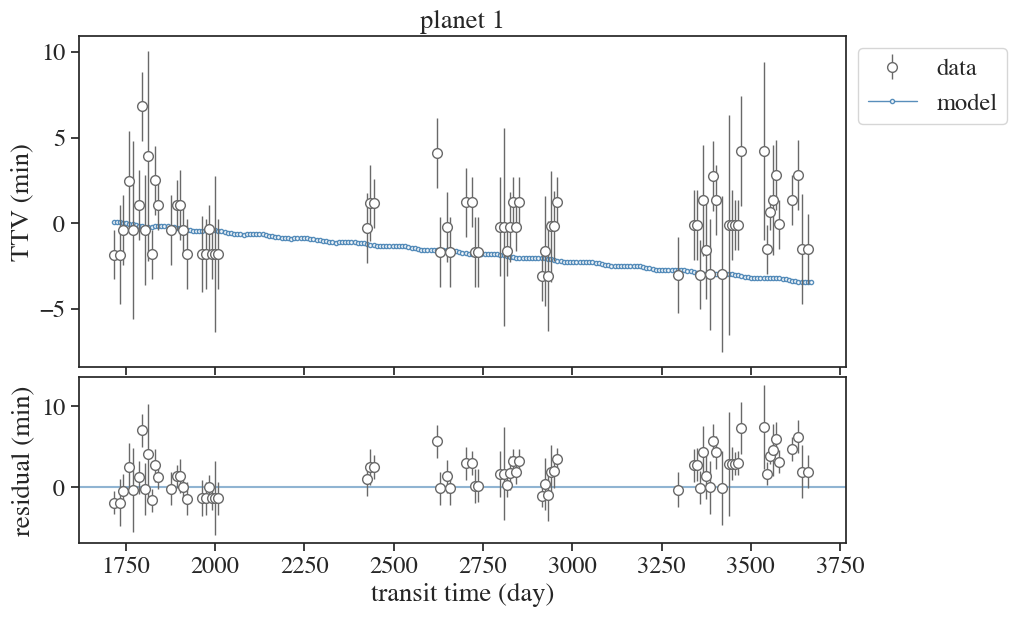

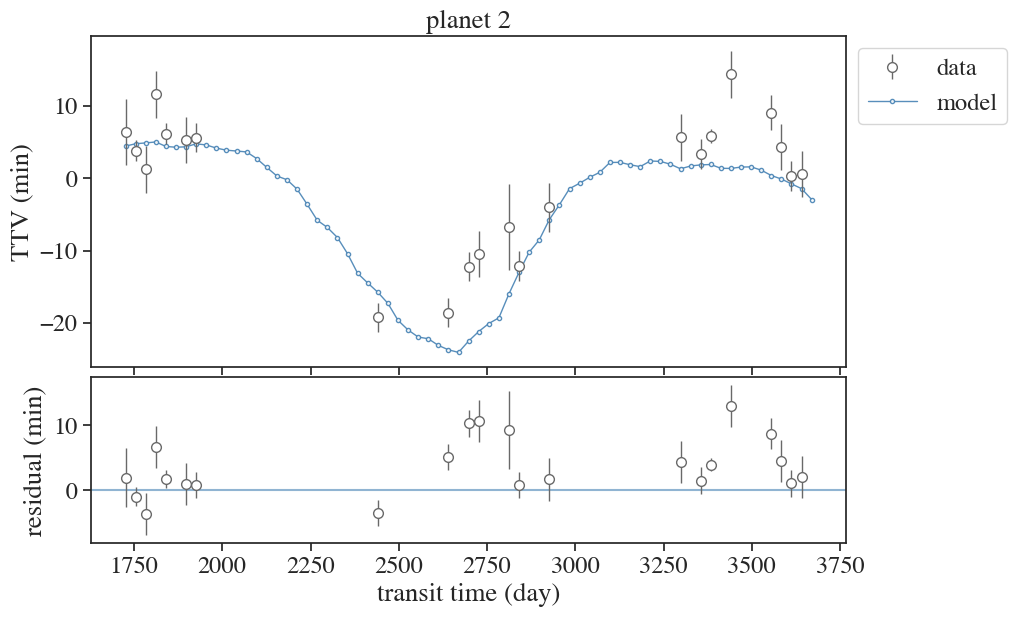

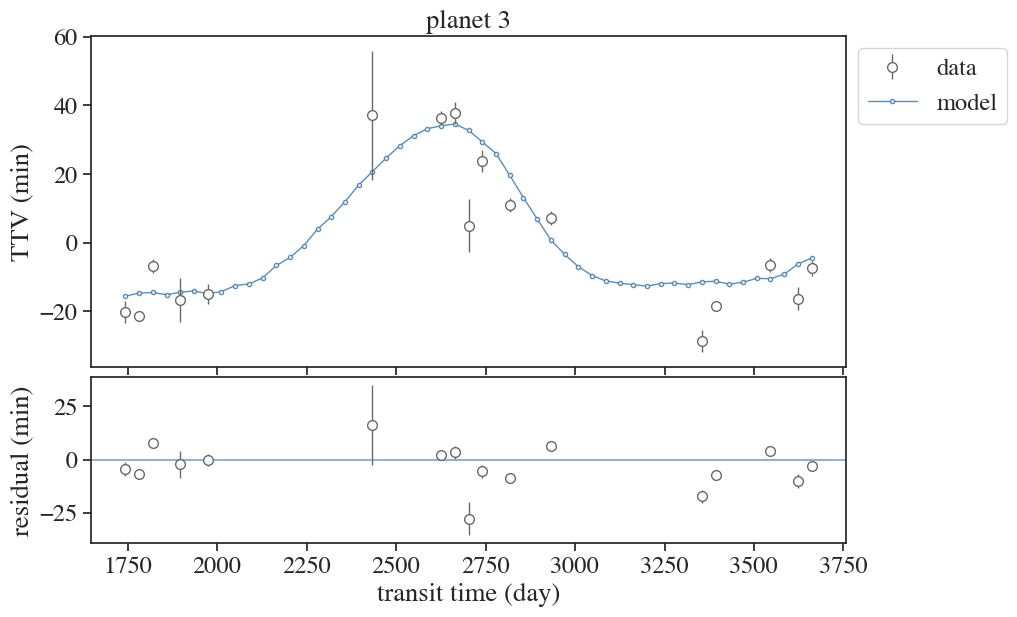

In [36]:
tcall = nt.get_transit_times_all_list(popt_full, truncate=False)
nt.plot_model(tcall, marker='.')
plt.show()

In [37]:
from astropy.constants import M_earth, M_sun
convert = M_sun.value / M_earth.value
print(1.48533451e-05*convert, 3.90801564e-06*convert, 2.36472194e-06*convert)

4.945363001098454 1.3011584813827624 0.7873248962593455


In [ ]:
from time import time
from numpyro.infer import MCMC, NUTS
# safer debugging config
kernel = NUTS(model_full, dense_mass=True, init_strategy=init_to_value(values=popt_full), max_tree_depth=8)
mcmc_test = MCMC(kernel, num_warmup=50, num_samples=100, num_chains=2, progress_bar=True)

t0 = time()
mcmc_test.run(random.PRNGKey(0), param_bounds_ttv, param_bounds_transit, extra_fields=('potential_energy', 'num_steps', 'adapt_state'))
t1 = time()
print(f"Elapsed: {t1-t0:.1f} s for (50 warmup + 100 samples) → ~{(t1-t0)/70:.3f} s per iteration (rough).")
mcmc_test.print_summary()

  0%|          | 0/150 [00:00<?, ?it/s]

  0%|          | 0/150 [00:00<?, ?it/s]

Elapsed: 18.0 s for (50 warmup + 100 samples) → ~0.257 s per iteration (rough).


In [38]:
import arviz as az
idata = az.from_numpyro(mcmc_test)

In [39]:
az.rcParams['plot.max_subplots'] = 100

In [40]:
keys_gp = ['lna', 'lnc', 'lnjitter']

/opt/homebrew/anaconda3/envs/tess-old/lib/python3.12/site-packages/arviz/stats/density_utils.py:488: UserWarning: Your data appears to have a single value or no finite values
  warnings.warn("Your data appears to have a single value or no finite values")
/opt/homebrew/anaconda3/envs/tess-old/lib/python3.12/site-packages/arviz/stats/density_utils.py:488: UserWarning: Your data appears to have a single value or no finite values
  warnings.warn("Your data appears to have a single value or no finite values")
/opt/homebrew/anaconda3/envs/tess-old/lib/python3.12/site-packages/arviz/stats/density_utils.py:488: UserWarning: Your data appears to have a single value or no finite values
  warnings.warn("Your data appears to have a single value or no finite values")
/opt/homebrew/anaconda3/envs/tess-old/lib/python3.12/site-packages/arviz/stats/density_utils.py:488: UserWarning: Your data appears to have a single value or no finite values
  warnings.warn("Your data appears to have a single value or

OverflowError: cannot convert float infinity to integer

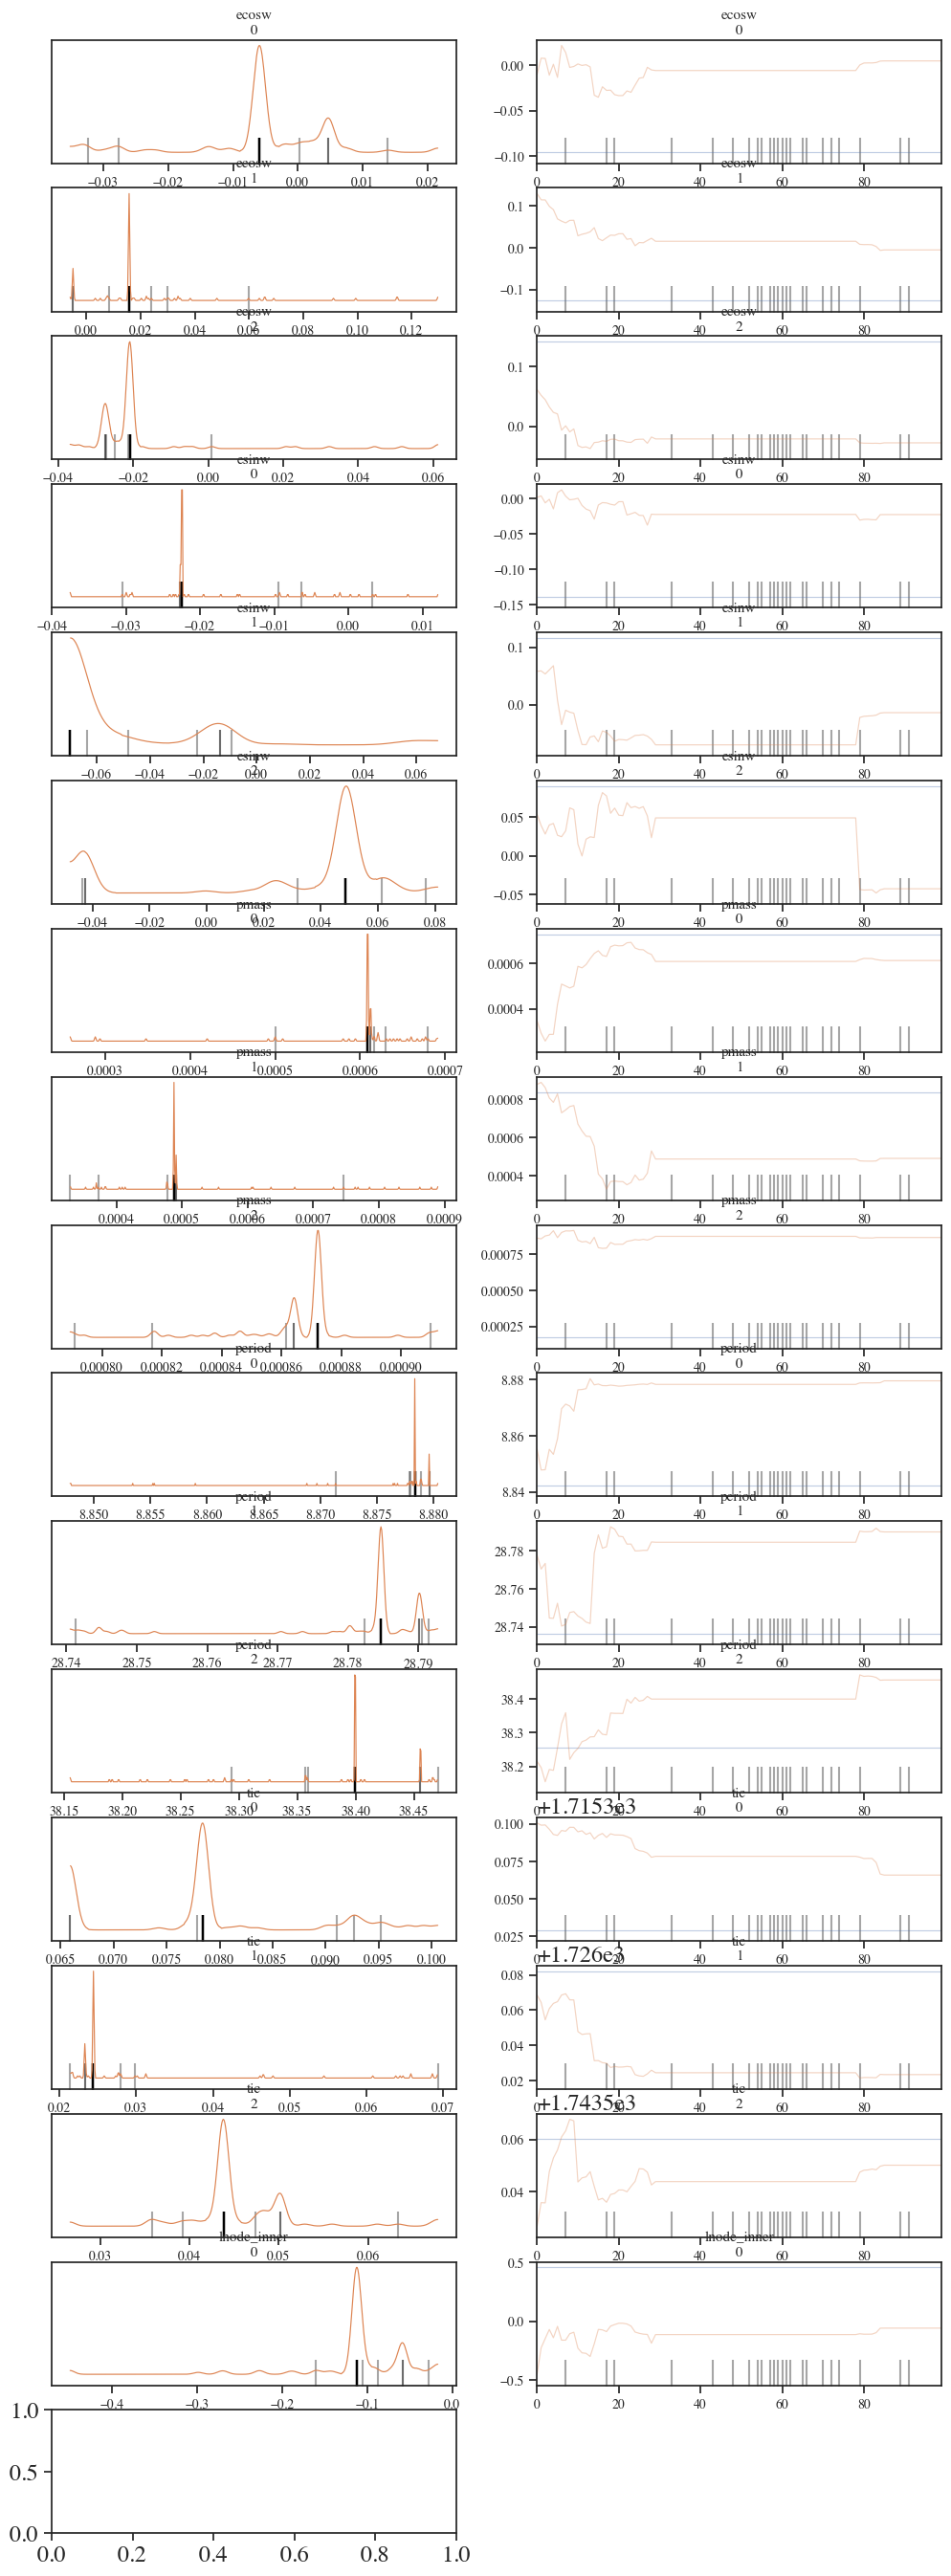

In [41]:
fig = az.plot_trace(mcmc_test, var_names=keys_ttv+['lnode_inner']+keys_transit+keys_gp, compact=False)
plt.tight_layout(pad=0.2)

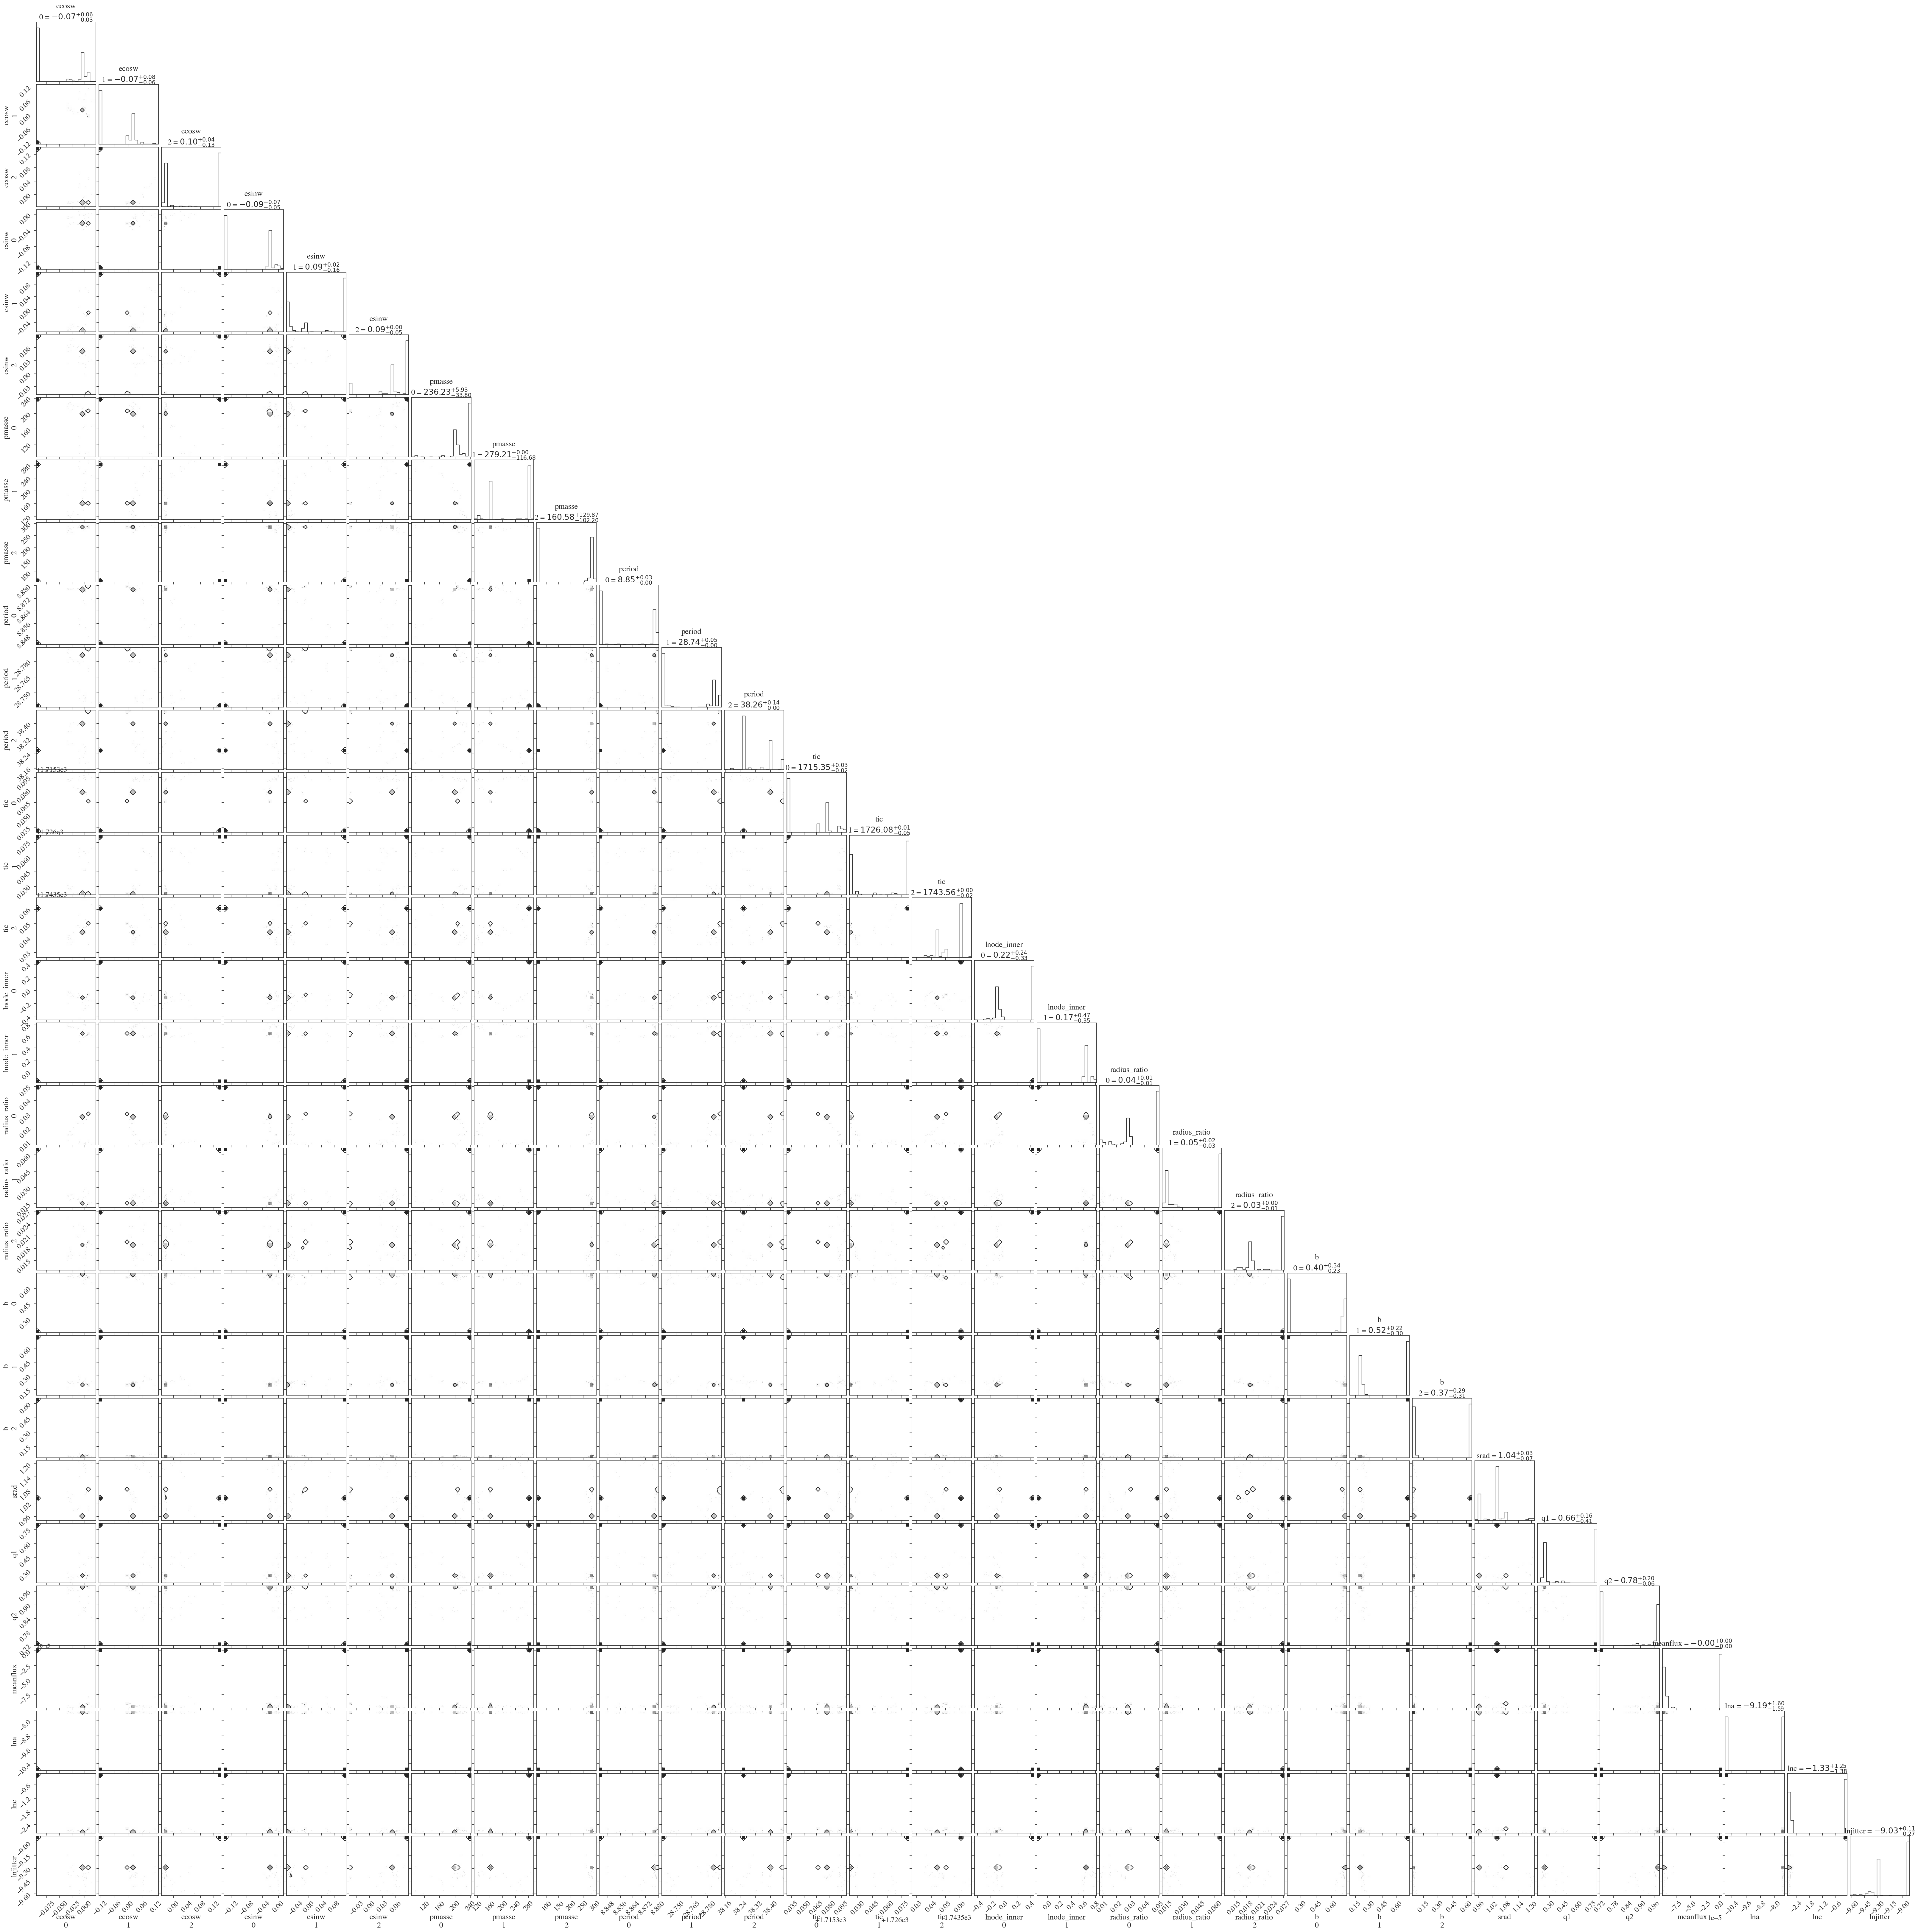

In [42]:
import corner
idata.posterior['pmasse'] = idata.posterior['pmass'] / 3.003e-6
keys_ttv_ = [key if key!="pmass" else "pmasse" for key in keys_ttv]
fig = corner.corner(idata, var_names=keys_ttv_+['lnode_inner']+keys_transit+keys_gp, show_titles=True)

In [ ]:
samples = mcmc.get_samples()
fmodels = samples['fluxmodel'] + samples['meanflux'][:,None] + samples['gppred']
mu_phys = np.mean(samples['fluxmodel'] + samples['meanflux'][:,None], axis=0)
mu, sigma = np.mean(fmodels, axis=0), np.std(fmodels, axis=0)

In [21]:
from numpyro.infer import MCMC, NUTS
kernel = NUTS(model_full, 
              dense_mass=True, 
              init_strategy=init_to_value(values=popt_full), 
              target_accept_prob=0.95,
              max_tree_depth=11)

In [22]:
mcmc = MCMC(kernel, num_warmup=50, num_samples=150, num_chains=num_chains)

In [23]:
from jax import random
rng_key = random.PRNGKey(0)
mcmc.run(rng_key, param_bounds_ttv, param_bounds_transit, extra_fields=('potential_energy', 'num_steps', 'adapt_state'), progress_bar=True)

  0%|          | 0/200 [00:00<?, ?it/s]

  0%|          | 0/200 [00:00<?, ?it/s]

  0%|          | 0/200 [00:00<?, ?it/s]

  0%|          | 0/200 [00:00<?, ?it/s]

In [ ]:
mcmc.print_summary()

In [ ]:
# save output
import dill
with open("toi1339_photodynamics_gp_mcmc.pkl", "wb") as f:
    dill.dump(mcmc, f)